# 📦 Transport Efficiency Analysis — Logistics KPI Dashboard

**Author:** Giuseppe Iaccarino  
**Date:** June 2022 — Revised 2026  
**Context:** Analysis of outbound transport routes from a central distribution warehouse, covering deliveries to retail points of sale (PDV) across 4 provinces in central Italy.

**Business Objective:**  
Measure and compare the efficiency of each delivery route using the KPI **Colli/KM** (cases delivered per km traveled). Identify underperforming routes and outliers to support logistics cost optimization decisions.

---
**Dataset:** anonymized transport records (~6 months, ~10,000+ trips)  
**Provinces analyzed:** MS · SP · RI · TR  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


## 2. Load & Clean Data

In [2]:
# skiprows=1: skips git conflict marker '<<<<<<< HEAD' on first line
data = pd.read_csv('DataAnalysis.csv', delimiter=';', skiprows=1, low_memory=False)

# Convert DATA_VIAGGIO to datetime — errors='coerce' turns unparsable rows into NaT
# (handles any residual conflict marker lines mid-file)
data['DATA_VIAGGIO'] = pd.to_datetime(data['DATA_VIAGGIO'], format='%d/%m/%Y', errors='coerce')
n_bad = data['DATA_VIAGGIO'].isna().sum()
if n_bad > 0:
    print(f'Dropped {n_bad} rows with unparsable dates (likely conflict markers)')
    data = data.dropna(subset=['DATA_VIAGGIO']).reset_index(drop=True)

# Replace placeholder dash values with NaN across the whole dataset
data.replace('-', np.nan, inplace=True)

# Force numeric columns (KM and COLLI may be read as strings due to mixed types)
# thousands='.' handles Italian number format (e.g. '1.234' = 1234)
for col in ['KM', 'COLLI']:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# FIX: replace zeros in KM with NaN (zero = missing data, not actual distance)
# These would otherwise produce infinite Colli/KM ratios
data['KM'].replace(0, np.nan, inplace=True)

# Anonymize PDV names for public sharing
pdv_map = {name: f'PDV_{i:04d}' for i, name in enumerate(data['RAGIONE_SOCIALE'].unique())}
data['PDV_ID'] = data['RAGIONE_SOCIALE'].map(pdv_map)

print(f'Dataset loaded: {len(data):,} rows, {data.shape[1]} columns')
print(f'Date range: {data["DATA_VIAGGIO"].min().date()} → {data["DATA_VIAGGIO"].max().date()}')
print(f'Provinces: {sorted(data["PROVINCIA"].dropna().unique())}')
print(f'KM missing (was zero): {data["KM"].isna().sum():,} rows ({data["KM"].isna().mean():.1%})')

Dropped 3 rows with unparsable dates (likely conflict markers)
Dataset loaded: 120,520 rows, 21 columns
Date range: 2022-01-03 → 2022-05-31
Provinces: ['AQ', 'AR', 'BO', 'FI', 'GR', 'LI', 'LU', 'MS', 'PG', 'PI', 'PO', 'PT', 'RI', 'SI', 'SP', 'TR', 'VT']
KM missing (was zero): 7,642 rows (6.3%)


## 3. Split by Province

In [3]:
ms = data[data['PROVINCIA'] == 'MS'].copy()
tr = data[data['PROVINCIA'] == 'TR'].copy()
sp = data[data['PROVINCIA'] == 'SP'].copy()
ri = data[data['PROVINCIA'] == 'RI'].copy()

province_summary = pd.DataFrame({
    'Province':   ['MS', 'SP', 'RI', 'TR'],
    'Trips':      [len(ms), len(sp), len(ri), len(tr)],
    'Unique PDV': [ms['RAGIONE_SOCIALE'].nunique(), sp['RAGIONE_SOCIALE'].nunique(),
                   ri['RAGIONE_SOCIALE'].nunique(), tr['RAGIONE_SOCIALE'].nunique()],
    'Avg KM':     [ms['KM'].mean(), sp['KM'].mean(), ri['KM'].mean(), tr['KM'].mean()],
    'Max KM':     [ms['KM'].max(), sp['KM'].max(), ri['KM'].max(), tr['KM'].max()],
})
province_summary = province_summary.round(1)
display(province_summary)

,Province,Trips,Unique PDV,Avg KM,Max KM
0,MS,5382,16,424.8,2330.0
1,SP,1328,7,484.9,1552.0
2,RI,1238,12,568.0,2206.0
3,TR,3096,29,449.0,2206.0


## 4. Build KPI: Colli/KM per Route

The **Colli/KM** index measures how many cases (colli) are delivered per kilometer traveled on each route.  
A higher value = better route saturation = lower cost per delivery.

In [4]:
def build_route_kpi(df, label):
    """
    Aggregates trip data by route (NOTE_VIAGGIO) and computes:
    - Mean cases (colli) per trip
    - Mean km per trip
    - Colli/KM efficiency index
    Drops routes where KM is missing/zero to avoid inf values.
    """
    viaggi = df['NOTE_VIAGGIO'].unique()
    result = pd.DataFrame({
        'Provincia':   label,
        'Viaggio':     viaggi,
        'Media_Colli': [df.loc[df['NOTE_VIAGGIO'] == v, 'COLLI'].mean() for v in viaggi],
        'Media_KM':    [df.loc[df['NOTE_VIAGGIO'] == v, 'KM'].mean() for v in viaggi],
        'N_Trips':     [df.loc[df['NOTE_VIAGGIO'] == v].shape[0] for v in viaggi],
    })
    # Drop routes with no valid KM data
    result = result[result['Media_KM'] > 0].copy()
    result['Colli_KM'] = result['Media_Colli'] / result['Media_KM']
    result = result.sort_values('Colli_KM', ascending=False).reset_index(drop=True)
    return result

df_ms = build_route_kpi(ms, 'MS')
df_sp = build_route_kpi(sp, 'SP')
df_ri = build_route_kpi(ri, 'RI')
df_tr = build_route_kpi(tr, 'TR')

# Combined dataframe
df_all = pd.concat([df_ms, df_sp, df_ri, df_tr], ignore_index=True)

print(f'Total routes analyzed: {len(df_all)}')
print(f'  MS: {len(df_ms)} routes')
print(f'  SP: {len(df_sp)} routes')
print(f'  RI: {len(df_ri)} routes')
print(f'  TR: {len(df_tr)} routes')

Total routes analyzed: 152
  MS: 57 routes
  SP: 19 routes
  RI: 28 routes
  TR: 48 routes


## 5. Outlier Detection & Removal (±3σ method)

Routes with Colli/KM more than 3 standard deviations from the mean are flagged as outliers.  
These typically correspond to special trips (taxi merci, empty returns, transit points) that distort the average.

In [5]:
def remove_outliers(df, col='Colli_KM', sigma=3):
    """
    Removes outliers using the ±3 standard deviations method.
    Returns (clean_df, outliers_df, stats_dict).
    """
    mean = df[col].mean()
    std  = df[col].std()
    lower = mean - sigma * std
    upper = mean + sigma * std

    clean    = df[(df[col] >= lower) & (df[col] <= upper)].copy()
    outliers = df[(df[col] < lower)  | (df[col] > upper)].copy()

    stats = {
        'mean_raw':   round(mean, 4),
        'mean_clean': round(clean[col].mean(), 4),
        'lower':      round(lower, 4),
        'upper':      round(upper, 4),
        'n_outliers': len(outliers),
        'n_clean':    len(clean),
    }
    return clean, outliers, stats

results = {}
for label, df in [('MS', df_ms), ('SP', df_sp), ('RI', df_ri), ('TR', df_tr)]:
    clean, outliers, stats = remove_outliers(df)
    results[label] = {'clean': clean, 'outliers': outliers, 'stats': stats}
    print(f'[{label}] Routes: {len(df)} → clean: {stats["n_clean"]}, outliers removed: {stats["n_outliers"]}'
          f'  |  Mean Colli/KM: {stats["mean_raw"]} → {stats["mean_clean"]} (after removal)')

[MS] Routes: 57 → clean: 57, outliers removed: 0  |  Mean Colli/KM: 0.2024 → 0.2024 (after removal)
[SP] Routes: 19 → clean: 19, outliers removed: 0  |  Mean Colli/KM: 0.1216 → 0.1216 (after removal)
[RI] Routes: 28 → clean: 27, outliers removed: 1  |  Mean Colli/KM: 0.3353 → 0.2746 (after removal)
[TR] Routes: 48 → clean: 48, outliers removed: 0  |  Mean Colli/KM: 0.2226 → 0.2226 (after removal)


## 6. Visualization — Colli/KM per Route by Province

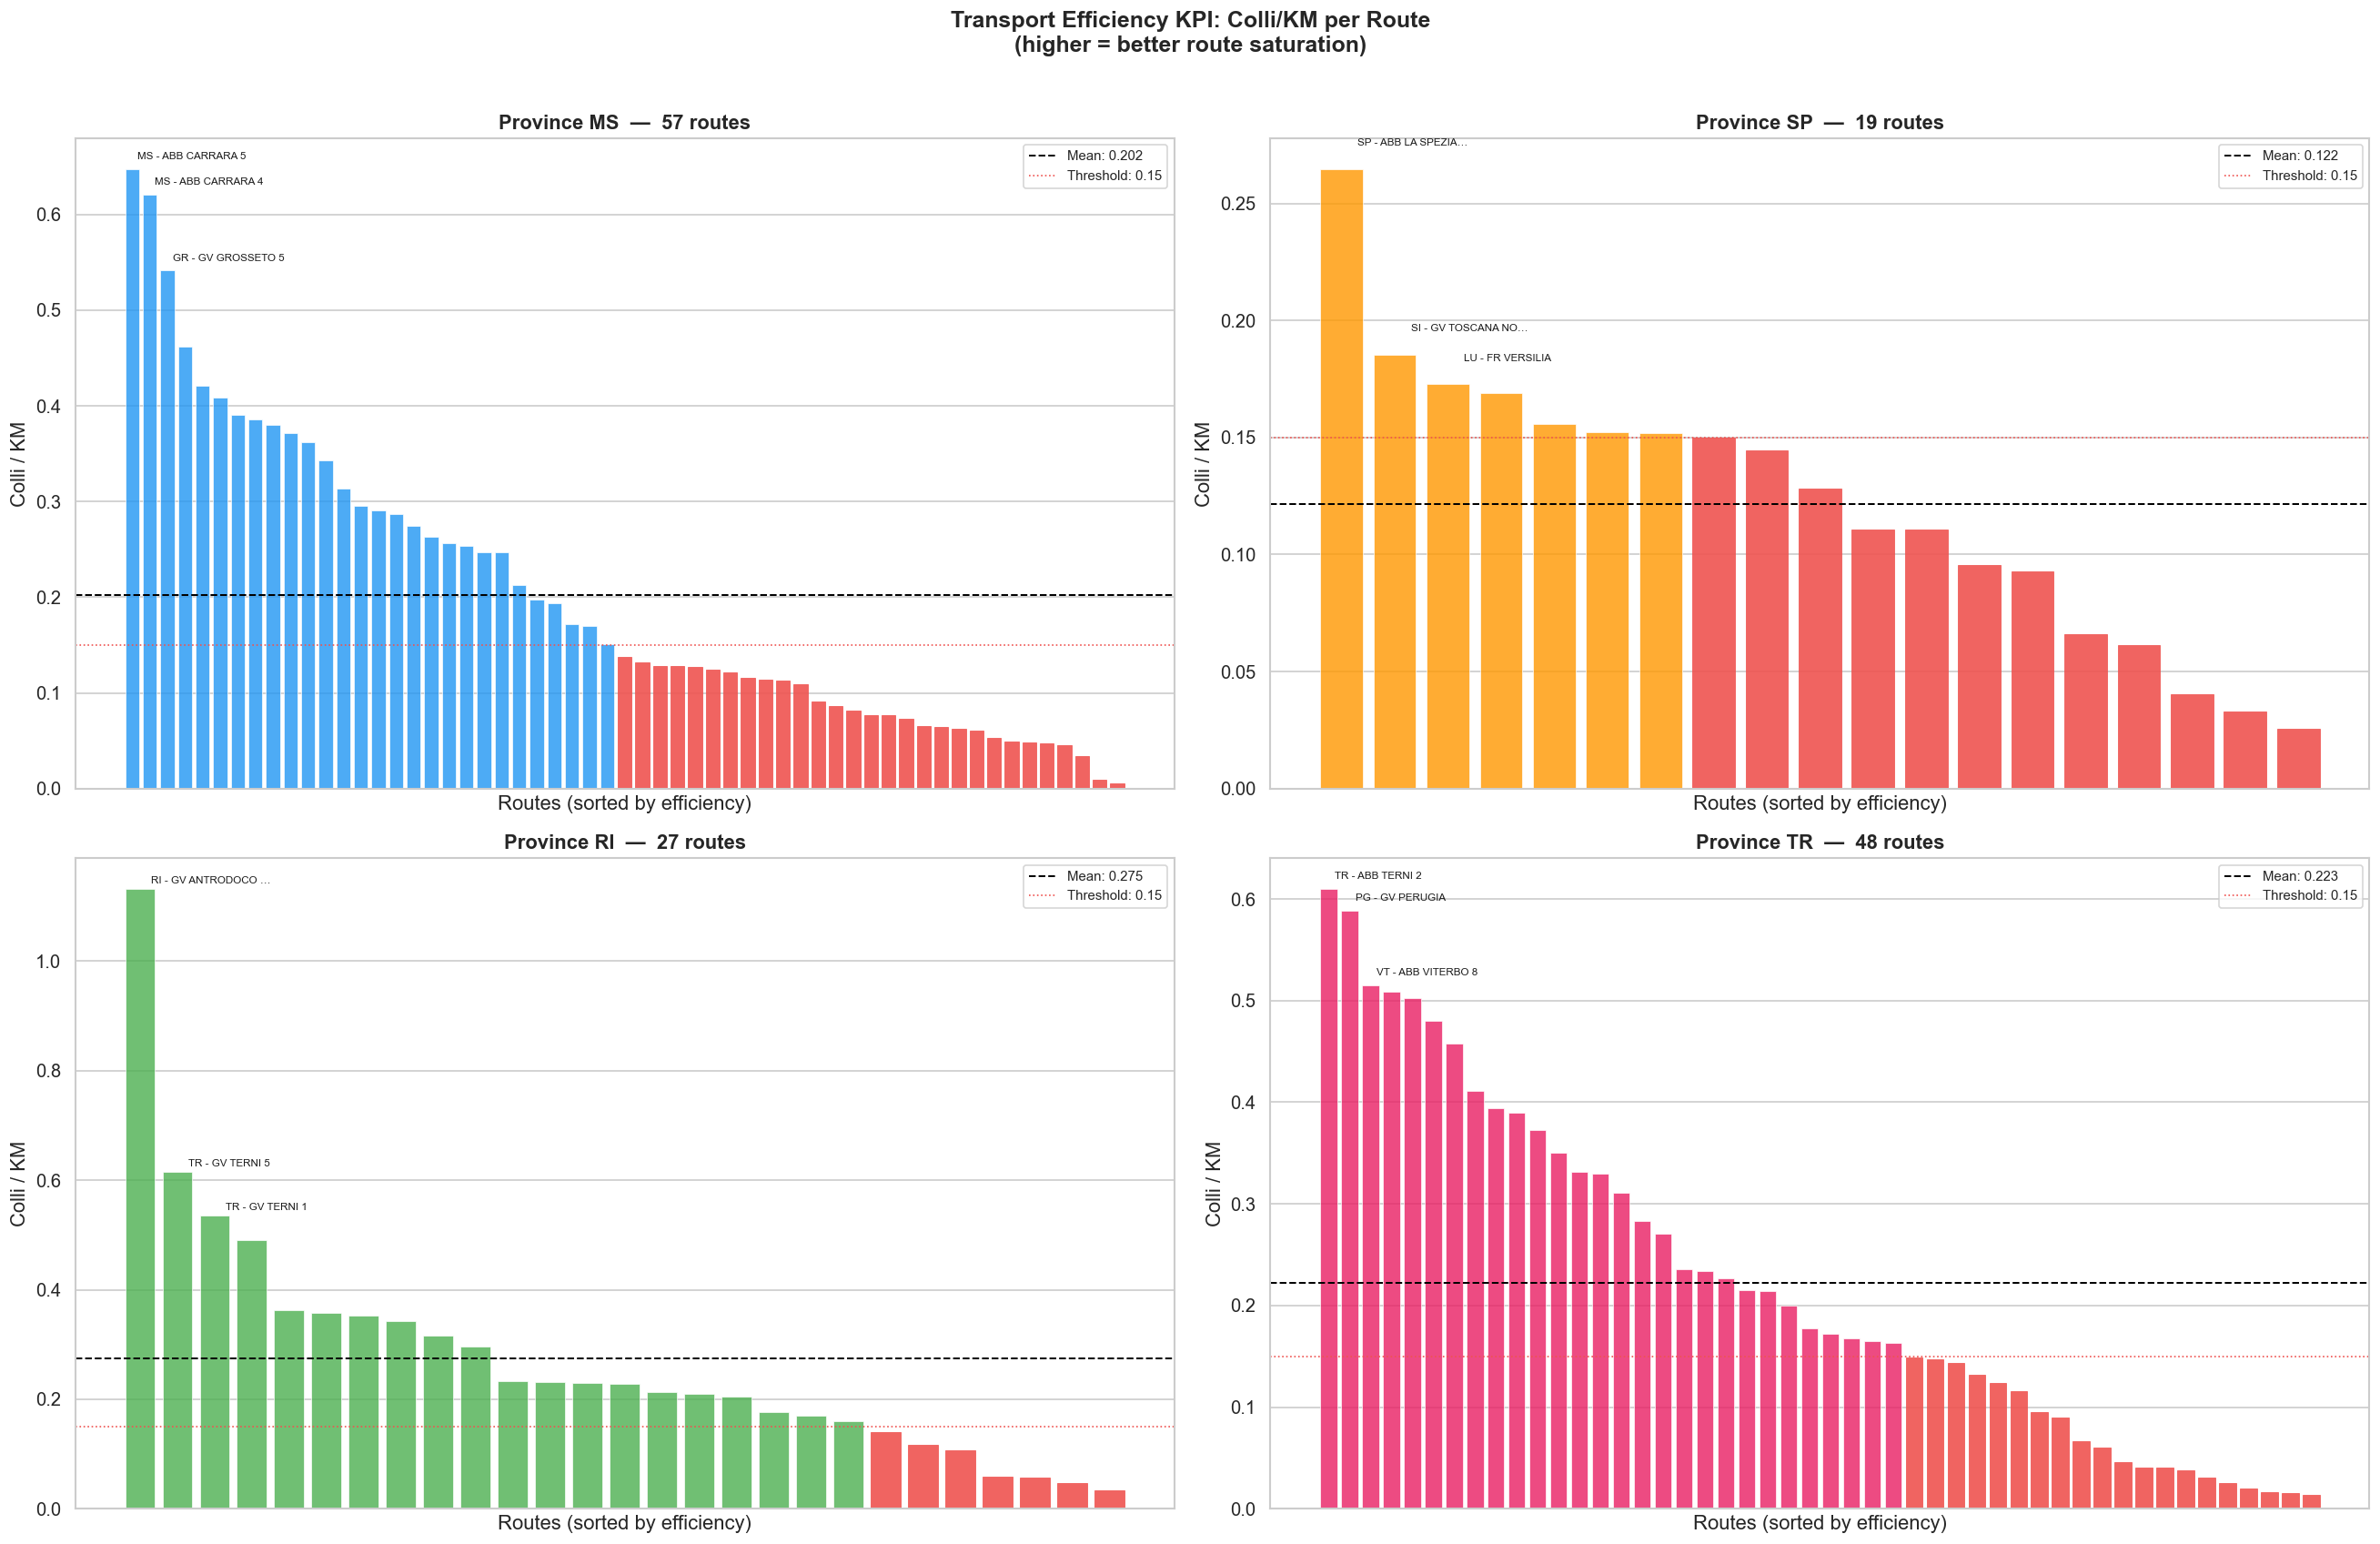

Chart saved → colli_km_by_province.png


In [6]:
COLORS = {'MS': '#2196F3', 'SP': '#FF9800', 'RI': '#4CAF50', 'TR': '#E91E63'}
THRESHOLD_LOW = 0.15   # below this = inefficient route

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.suptitle('Transport Efficiency KPI: Colli/KM per Route\n(higher = better route saturation)',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (label, res) in zip(axes.flatten(), results.items()):
    df_clean = res['clean'].sort_values('Colli_KM', ascending=False)
    mean_val = df_clean['Colli_KM'].mean()

    bars = ax.bar(range(len(df_clean)), df_clean['Colli_KM'],
                  color=COLORS[label], alpha=0.8, edgecolor='white', linewidth=0.5)

    # Color bars below threshold red
    for bar, val in zip(bars, df_clean['Colli_KM']):
        if val < THRESHOLD_LOW:
            bar.set_color('#EF5350')
            bar.set_alpha(0.9)

    # Mean line
    ax.axhline(mean_val, color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {mean_val:.3f}')
    # Threshold line
    ax.axhline(THRESHOLD_LOW, color='#EF5350', linestyle=':', linewidth=1,
               label=f'Threshold: {THRESHOLD_LOW}')

    ax.set_title(f'Province {label}  —  {len(df_clean)} routes', fontweight='bold')
    ax.set_ylabel('Colli / KM')
    ax.set_xlabel('Routes (sorted by efficiency)')
    ax.set_xticks([])
    ax.legend(fontsize=9)

    # Annotate top 3
    for i, (_, row) in enumerate(df_clean.head(3).iterrows()):
        short = row['Viaggio'][:18] + '…' if len(row['Viaggio']) > 18 else row['Viaggio']
        ax.annotate(short, xy=(i, row['Colli_KM']),
                    xytext=(i + 0.3, row['Colli_KM'] + 0.01),
                    fontsize=7, color='#1a1a1a')

plt.tight_layout()
plt.savefig('colli_km_by_province.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved → colli_km_by_province.png')

## 7. Cross-Province Comparison

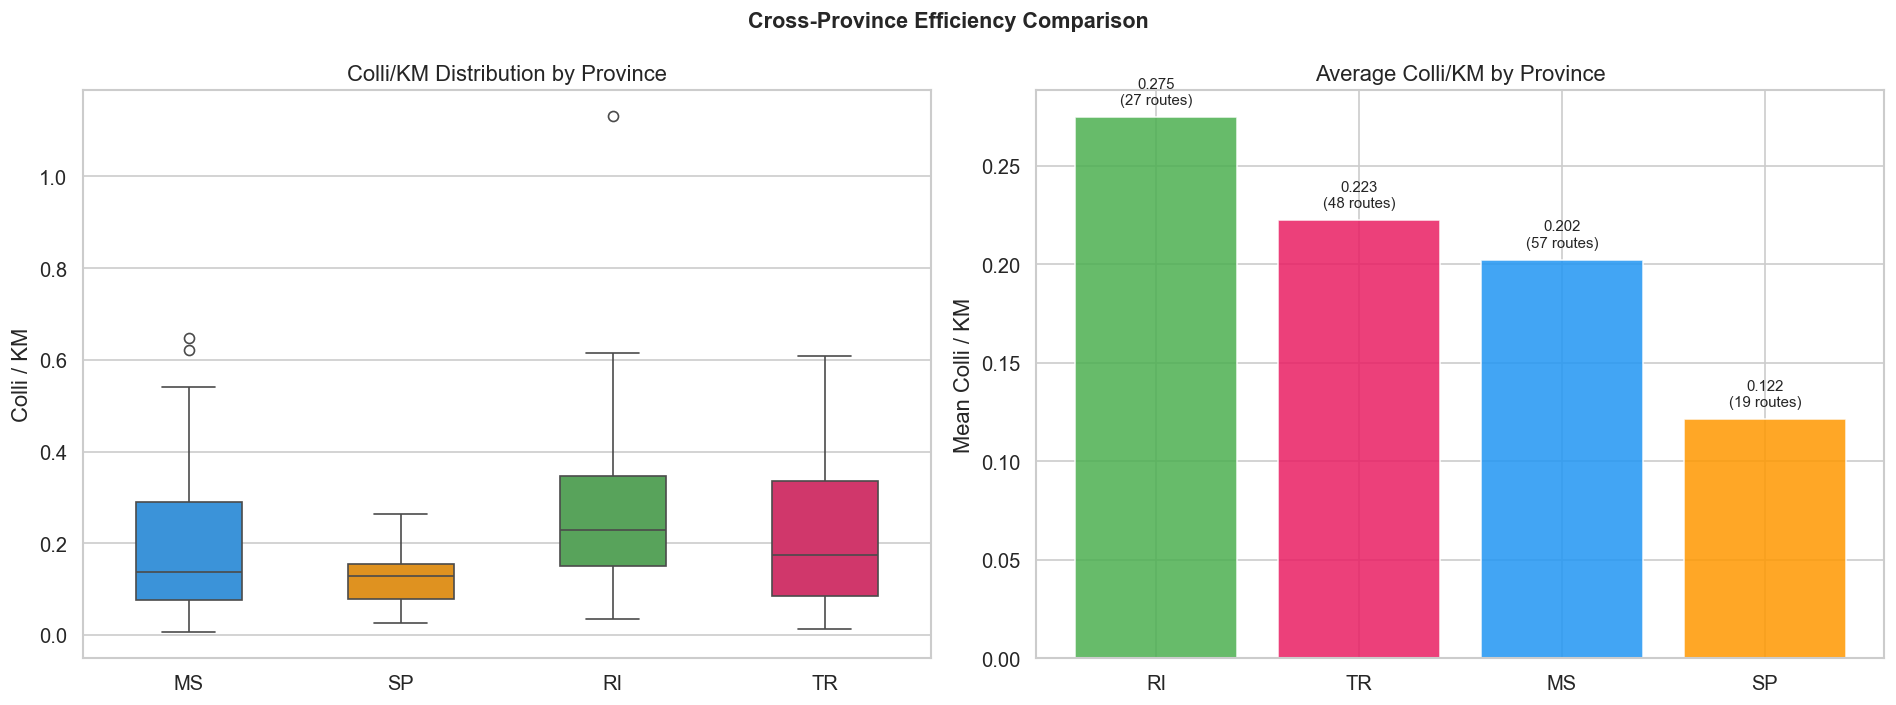

Chart saved → cross_province_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cross-Province Efficiency Comparison', fontsize=13, fontweight='bold')

# --- Left: boxplot Colli/KM distribution ---
plot_data = pd.concat([res['clean'].assign(Provincia=label)
                       for label, res in results.items()])

sns.boxplot(data=plot_data, x='Provincia', y='Colli_KM',
            hue='Provincia', palette=COLORS, legend=False, ax=axes[0], width=0.5)
axes[0].set_title('Colli/KM Distribution by Province')
axes[0].set_ylabel('Colli / KM')
axes[0].set_xlabel('')

# --- Right: summary bar chart ---
summary = pd.DataFrame([
    {
        'Provincia': label,
        'Mean Colli/KM': res['clean']['Colli_KM'].mean(),
        'Routes': len(res['clean']),
        'Low efficiency routes': (res['clean']['Colli_KM'] < THRESHOLD_LOW).sum(),
    }
    for label, res in results.items()
]).sort_values('Mean Colli/KM', ascending=False)

bars = axes[1].bar(summary['Provincia'], summary['Mean Colli/KM'],
                   color=[COLORS[p] for p in summary['Provincia']],
                   alpha=0.85, edgecolor='white')
axes[1].set_title('Average Colli/KM by Province')
axes[1].set_ylabel('Mean Colli / KM')
axes[1].set_xlabel('')

for bar, (_, row) in zip(bars, summary.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{row['Mean Colli/KM']:.3f}\n({row['Routes']} routes)",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cross_province_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved → cross_province_comparison.png')

## 8. Inefficient Routes — Action List

Routes below the efficiency threshold (Colli/KM < 0.15) are candidates for:
- Route consolidation (merge with adjacent routes)
- Frequency reduction
- Carrier renegotiation

In [8]:
low_efficiency = plot_data[plot_data['Colli_KM'] < THRESHOLD_LOW].copy()
low_efficiency = low_efficiency[['Provincia', 'Viaggio', 'Media_Colli', 'Media_KM',
                                  'Colli_KM', 'N_Trips']]
low_efficiency = low_efficiency.sort_values(['Provincia', 'Colli_KM']).reset_index(drop=True)
low_efficiency.columns = ['Province', 'Route', 'Avg Cases', 'Avg KM', 'Colli/KM', 'N Trips']
low_efficiency = low_efficiency.round(3)

print(f'Routes below efficiency threshold ({THRESHOLD_LOW}): {len(low_efficiency)}')
try:
    import jinja2
    display(low_efficiency.style
            .background_gradient(subset=['Colli/KM'], cmap='RdYlGn')
            .format({'Avg Cases': '{:.1f}', 'Avg KM': '{:.1f}', 'Colli/KM': '{:.4f}'})
           )
except ImportError:
    fmt = low_efficiency.copy()
    fmt['Avg Cases']  = fmt['Avg Cases'].map('{:.1f}'.format)
    fmt['Avg KM']     = fmt['Avg KM'].map('{:.1f}'.format)
    fmt['Colli/KM']   = fmt['Colli/KM'].map('{:.4f}'.format)
    display(fmt)

Routes below efficiency threshold (0.15): 68


,Province,Route,Avg Cases,Avg KM,Colli/KM,N Trips
0,MS,X - VUOTI GRIFOGEL,2.0,352.0,0.0060,2
1,MS,X - NAVETTAGGIO MONTERIGGIONI 1,4.0,423.0,0.0090,2
2,MS,PT - GV PRATO,13.0,383.0,0.0340,4
3,MS,LU - ABB LUCCA 3,17.7,387.3,0.0460,30
4,MS,TX - TAXI MERCI,81.6,1735.0,0.0470,54
5,MS,LU - ABB LUCCA 11,17.0,350.2,0.0490,10
6,MS,LU - FR LUCCA 1,19.7,397.5,0.0490,32
7,MS,SP - GV LA SPEZIA 1,24.9,472.8,0.0530,54
8,MS,SP - GV LA SPEZIA,26.1,433.0,0.0600,14
9,MS,SI - GV TOSCANA NORD 2,27.0,429.0,0.0630,10


## 9. Geographic Distribution of Delivery Points

Scatter plot of all PDV (points of sale) served, plotted by GPS coordinates from `coordinate.csv`.  
Left panel shows all provinces together; right panel breaks down each province individually.  
Helps visually identify geographic clusters, route coverage density, and potential consolidation areas.

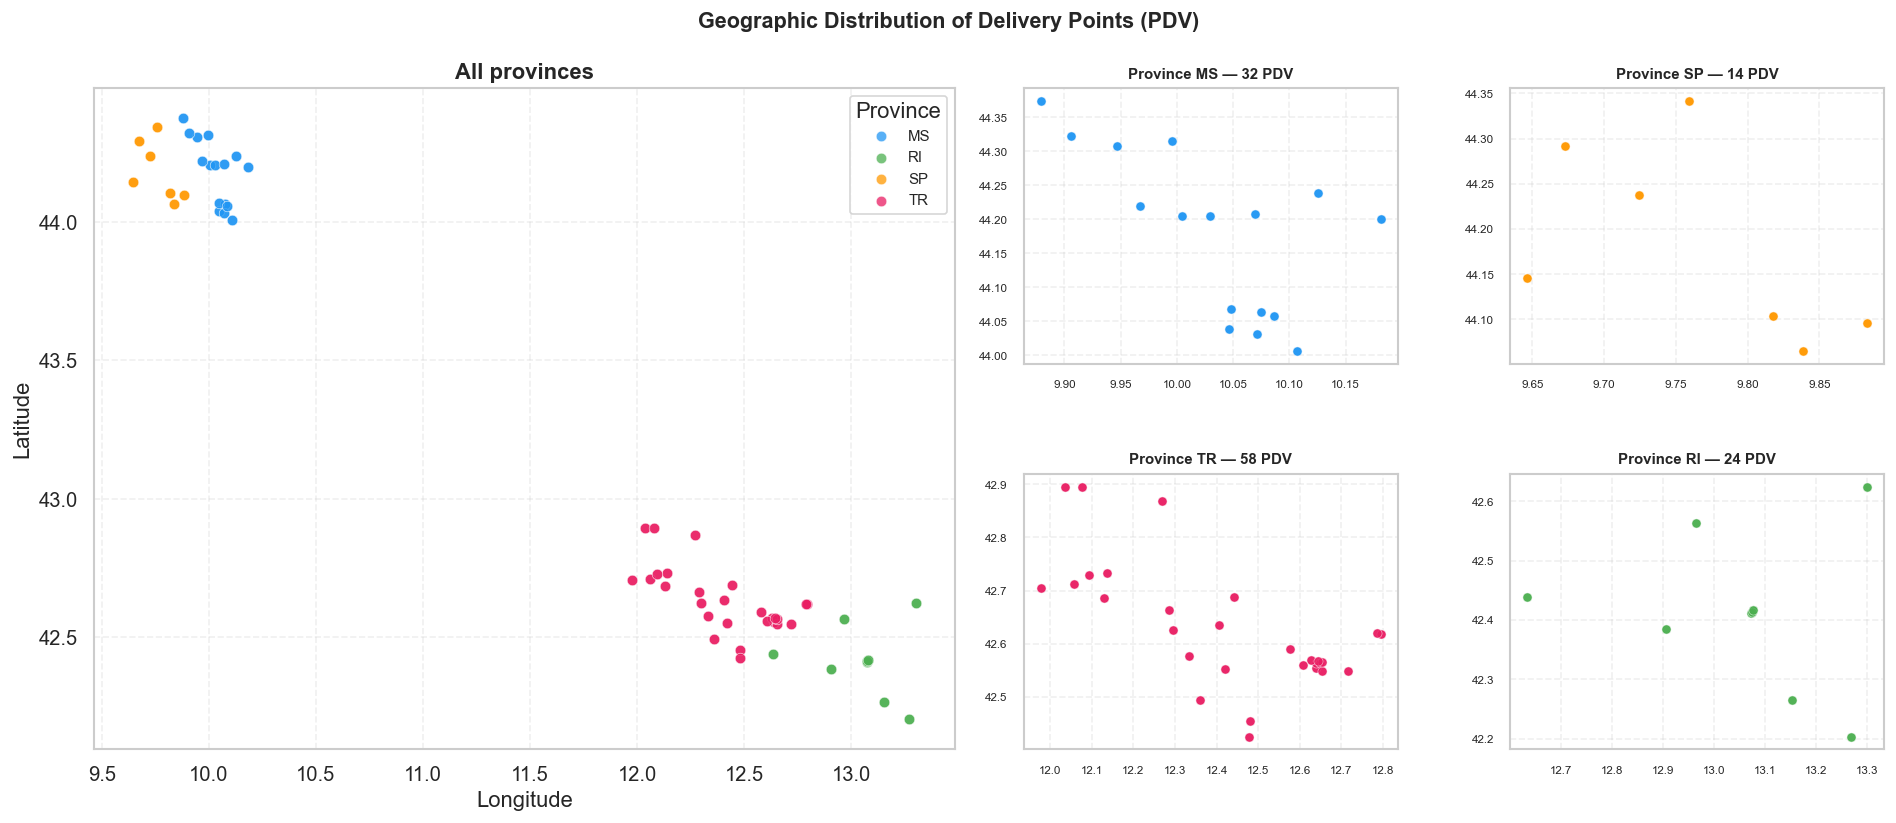

PDV totali: 128
PROV
MS    32
RI    24
SP    14
TR    58


In [9]:
# ── Geographic distribution of PDV — matplotlib scatter ───────────────────
# Renders inline on GitHub. coordinate.csv has a conflict marker on line 1 → skiprows=1.
try:
    coord = pd.read_csv('coordinate.csv', delimiter=';', skiprows=1,
                        names=['PDV', 'RAGIONE_SOCIALE', 'PROV', 'COORDINATE'])
    coord[['lat', 'lng']] = coord['COORDINATE'].str.split(', ', expand=True)
    coord['lat'] = pd.to_numeric(coord['lat'], errors='coerce')
    coord['lng'] = pd.to_numeric(coord['lng'], errors='coerce')
    coord = coord.dropna(subset=['lat', 'lng'])

    PROV_COLORS = {'MS': '#2196F3', 'SP': '#FF9800', 'TR': '#E91E63', 'RI': '#4CAF50'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Geographic Distribution of Delivery Points (PDV)', fontsize=13, fontweight='bold')

    # ── Left: all provinces together ──────────────────────────────────────
    for prov, grp in coord.groupby('PROV'):
        color = PROV_COLORS.get(prov, '#999')
        axes[0].scatter(grp['lng'], grp['lat'], c=color, s=40, alpha=0.75,
                        edgecolors='white', linewidths=0.4, label=prov)
    axes[0].set_title('All provinces', fontweight='bold')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].legend(title='Province', fontsize=9)
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # ── Right: 2×2 facet per province ─────────────────────────────────────
    from matplotlib.gridspec import GridSpecFromSubplotSpec
    axes[1].remove()
    gs = GridSpecFromSubplotSpec(2, 2, subplot_spec=fig.add_gridspec(1, 2)[1], hspace=0.4, wspace=0.3)
    for idx, prov in enumerate(['MS', 'SP', 'TR', 'RI']):
        ax = fig.add_subplot(gs[idx // 2, idx % 2])
        grp = coord[coord['PROV'] == prov]
        color = PROV_COLORS.get(prov, '#999')
        ax.scatter(grp['lng'], grp['lat'], c=color, s=30, alpha=0.8,
                   edgecolors='white', linewidths=0.3)
        ax.set_title(f'Province {prov} — {len(grp)} PDV', fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('pdv_geographic_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"PDV totali: {len(coord)}")
    print(coord.groupby('PROV').size().rename('N_PDV').to_string())

except FileNotFoundError:
    print("[!] coordinate.csv not found — skipping geographic map.")

## 10. Cost per Case by Delivery Day

Breaking down **Costo_per_collo** by weekday reveals whether certain delivery days are systematically less efficient.  
This dimension is invisible in the route-level analysis but critical for scheduling optimization.

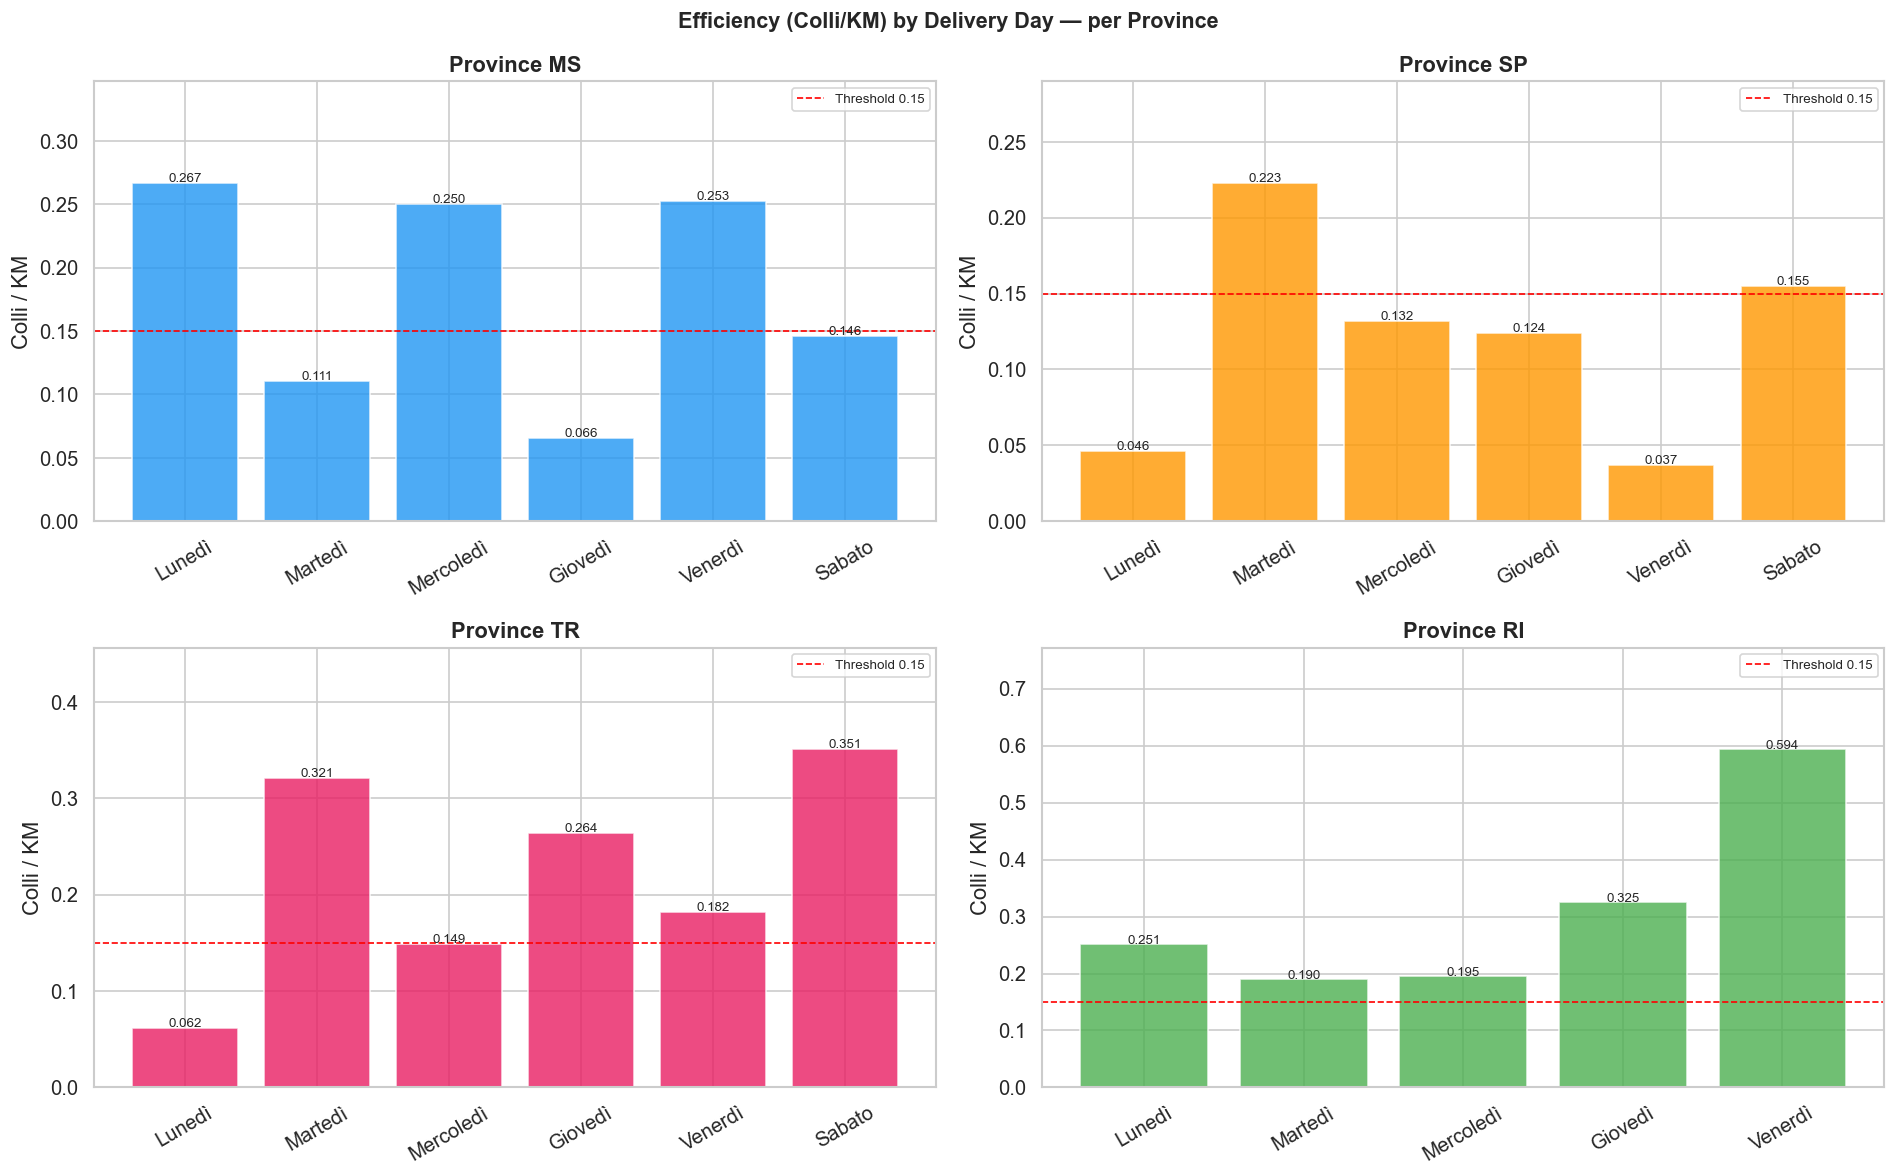

In [10]:
# ── Build weekday KPI table per province ──────────────────────────────────
# Uses Colli/KM as efficiency index (no trip cost column in this dataset).
# A lower Colli/KM on a given day means fewer cases delivered per km — less efficient.
WEEK_ORDER = ['lun', 'mar', 'mer', 'gio', 'ven', 'sab']
WEEK_LABELS = {'lun': 'Lunedì', 'mar': 'Martedì', 'mer': 'Mercoledì',
               'gio': 'Giovedì', 'ven': 'Venerdì', 'sab': 'Sabato'}

province_map = {'MS': ms, 'SP': sp, 'TR': tr, 'RI': ri}

def build_weekday_kpi(df_prov):
    wk = [d for d in WEEK_ORDER if d in df_prov['GIORNO_WK'].values]
    rows = []
    for d in wk:
        sub = df_prov[df_prov['GIORNO_WK'] == d]
        colli = sub['COLLI'].mean()
        km    = sub['KM'].dropna().mean()
        colli_km = (colli / km) if (km > 0 and colli > 0) else np.nan
        rows.append({
            'Giorno':     WEEK_LABELS.get(d, d),
            'Media_Colli': round(colli, 1),
            'Media_KM':    round(km, 1) if pd.notna(km) else np.nan,
            'Colli_KM':    round(colli_km, 3) if pd.notna(colli_km) else np.nan,
            'N_Viaggi':    len(sub)
        })
    return pd.DataFrame(rows)

wk_kpi = {prov: build_weekday_kpi(df) for prov, df in province_map.items()}

# ── Plot: Colli/KM by weekday, 2×2 grid ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Efficiency (Colli/KM) by Delivery Day — per Province', fontsize=13, fontweight='bold')

for ax, (prov, df_wk) in zip(axes.flatten(), wk_kpi.items()):
    if df_wk.empty or df_wk['Colli_KM'].dropna().empty:
        ax.set_title(f'Province {prov} — no data')
        continue
    color = COLORS.get(prov, '#999')
    bars = ax.bar(df_wk['Giorno'], df_wk['Colli_KM'],
                  color=color, alpha=0.8, edgecolor='white')
    ax.axhline(THRESHOLD_LOW, color='red', linestyle='--', linewidth=1, label=f'Threshold {THRESHOLD_LOW}')
    ax.set_title(f'Province {prov}', fontweight='bold')
    ax.set_ylabel('Colli / KM')
    ymax = df_wk['Colli_KM'].replace([np.inf, -np.inf], np.nan).max()
    ax.set_ylim(0, ymax * 1.30 if pd.notna(ymax) and ymax > 0 else 1)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, df_wk['Colli_KM']):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('weekday_efficiency_by_province.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Cost per Case by Delivery Day × Product Category

Adding **product category (merceologia)** as a dimension reveals which category drives inefficiency on specific days.  
In a multi-temperature distribution network (secco / fresco / surgelato), this matters because each category has different loading constraints and vehicle requirements.

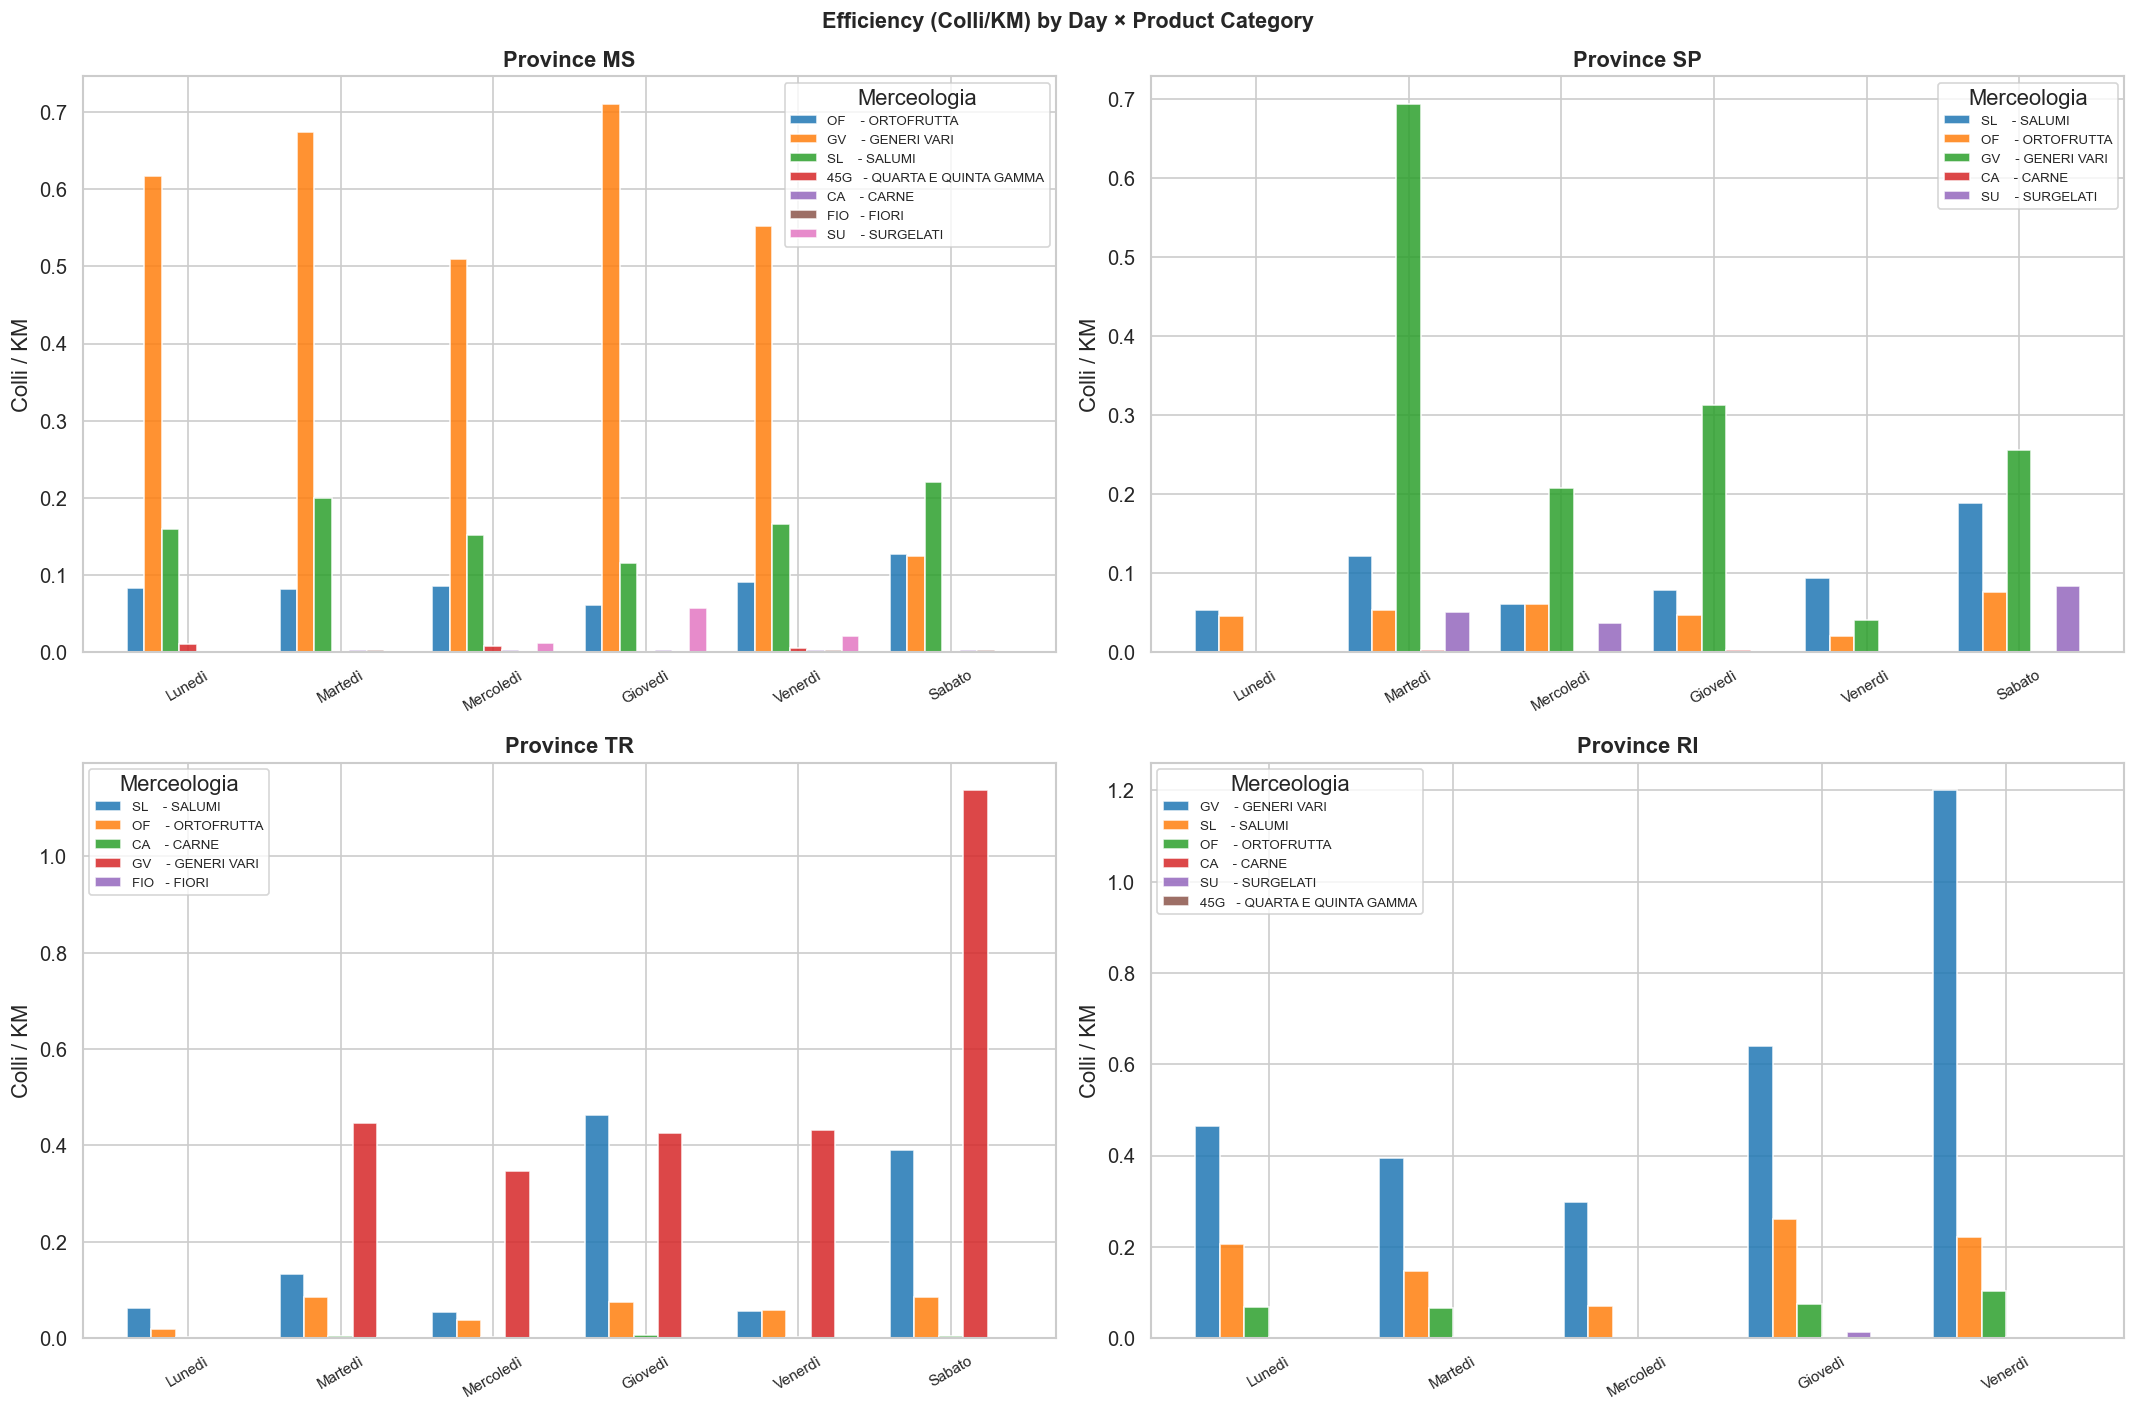

In [11]:
# ── Build day × merceologia KPI ────────────────────────────────────────────
def build_merc_kpi(df_prov):
    if 'MERCEOLOGIA' not in df_prov.columns:
        return pd.DataFrame()
    wk   = [d for d in WEEK_ORDER if d in df_prov['GIORNO_WK'].values]
    sett = df_prov['MERCEOLOGIA'].dropna().unique()
    rows = []
    for d in wk:
        for s in sett:
            sub = df_prov[(df_prov['GIORNO_WK'] == d) & (df_prov['MERCEOLOGIA'] == s)]
            if sub.empty:
                continue
            colli = sub['COLLI'].mean()
            km    = sub['KM'].dropna().mean()
            colli_km = (colli / km) if (pd.notna(km) and km > 0 and colli > 0) else np.nan
            rows.append({
                'Giorno':      WEEK_LABELS.get(d, d),
                'Merceologia': s,
                'Colli_KM':    round(colli_km, 3) if pd.notna(colli_km) else np.nan,
                'Media_Colli': round(colli, 1)
            })
    return pd.DataFrame(rows).dropna(subset=['Colli_KM'])

merc_kpi = {prov: build_merc_kpi(df) for prov, df in province_map.items()}

# ── Plot: grouped barplot per province ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Efficiency (Colli/KM) by Day × Product Category', fontsize=13, fontweight='bold')

for ax, (prov, df_m) in zip(axes.flatten(), merc_kpi.items()):
    if df_m.empty:
        ax.set_title(f'{prov} — no MERCEOLOGIA data')
        continue
    giorni = [WEEK_LABELS.get(d, d) for d in WEEK_ORDER if WEEK_LABELS.get(d, d) in df_m['Giorno'].values]
    sett   = df_m['Merceologia'].unique()
    x      = range(len(giorni))
    width  = 0.8 / max(len(sett), 1)
    palette = plt.cm.tab10.colors

    for i, s in enumerate(sett):
        sub  = df_m[df_m['Merceologia'] == s].set_index('Giorno')
        vals = [sub.loc[g, 'Colli_KM'] if g in sub.index else 0 for g in giorni]
        ax.bar([xi + i * width for xi in x], vals, width=width,
               label=s, color=palette[i % 10], alpha=0.85, edgecolor='white')

    ax.set_title(f'Province {prov}', fontweight='bold')
    ax.set_ylabel('Colli / KM')
    ax.set_xticks([xi + width * (len(sett) - 1) / 2 for xi in x])
    ax.set_xticklabels(giorni, rotation=30, fontsize=9)
    ax.legend(fontsize=8, title='Merceologia')

plt.tight_layout()
plt.savefig('merceologia_efficiency_by_day.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Operational Recommendations

Based on the route-level analysis (sections 4–8) and the weekday × category breakdown (sections 10–11):

In [12]:
# ── Operational recommendations from weekday efficiency data ──────────────
recommendations = []

for prov, df_wk in wk_kpi.items():
    if df_wk.empty or df_wk['Colli_KM'].dropna().empty:
        continue
    df_valid = df_wk.dropna(subset=['Colli_KM'])
    if len(df_valid) < 2:
        continue
    min_day = df_valid.loc[df_valid['Colli_KM'].idxmin()]
    max_day = df_valid.loc[df_valid['Colli_KM'].idxmax()]
    gap = max_day['Colli_KM'] - min_day['Colli_KM']
    if gap > 0.05:  # meaningful efficiency gap between days
        recommendations.append(
            f"  [{prov}] Worst day: {min_day['Giorno']} "
            f"({min_day['Colli_KM']:.3f} colli/km, n={int(min_day['N_Viaggi'])}) — "
            f"best: {max_day['Giorno']} ({max_day['Colli_KM']:.3f} colli/km). "
            f"Gap: {gap:.3f} — review load consolidation on {min_day['Giorno']}."
        )

print('=' * 70)
print('  OPERATIONAL RECOMMENDATIONS — WEEKDAY SCHEDULING')
print('=' * 70)
if recommendations:
    for r in recommendations:
        print(r)
        print()
else:
    print("  No significant weekday efficiency gaps detected (threshold: 0.05 colli/km).")

print()
print('  NOTES FROM ORIGINAL ANALYSIS:')
print('  • OF+SL category on Thursday (MS+SP) shows lowest Colli/KM.')
print('    Candidate for consolidation with Wednesday or Friday run.')
print('  • Tuesday (MS+SP): borderline — review load factor before cutting.')
print('  • Geographic clustering near Massa-Carrara coast visible on map:')
print('    potential for a dedicated coastal sub-route to reduce km per stop.')
print('=' * 70)

  OPERATIONAL RECOMMENDATIONS — WEEKDAY SCHEDULING
  [MS] Worst day: Giovedì (0.066 colli/km, n=260) — best: Lunedì (0.267 colli/km). Gap: 0.201 — review load consolidation on Giovedì.

  [SP] Worst day: Venerdì (0.037 colli/km, n=38) — best: Martedì (0.223 colli/km). Gap: 0.186 — review load consolidation on Venerdì.

  [TR] Worst day: Lunedì (0.062 colli/km, n=272) — best: Sabato (0.351 colli/km). Gap: 0.289 — review load consolidation on Lunedì.

  [RI] Worst day: Martedì (0.190 colli/km, n=50) — best: Venerdì (0.594 colli/km). Gap: 0.404 — review load consolidation on Martedì.


  NOTES FROM ORIGINAL ANALYSIS:
  • OF+SL category on Thursday (MS+SP) shows lowest Colli/KM.
    Candidate for consolidation with Wednesday or Friday run.
  • Tuesday (MS+SP): borderline — review load factor before cutting.
  • Geographic clustering near Massa-Carrara coast visible on map:
    potential for a dedicated coastal sub-route to reduce km per stop.


## 13. Executive Summary

> *This section synthesizes the analytical findings into actionable business insights — the output a Controller would present to management.*

In [13]:
print('=' * 65)
print('  TRANSPORT EFFICIENCY ANALYSIS — EXECUTIVE SUMMARY')
print('=' * 65)

best_province = summary.iloc[0]
worst_province = summary.iloc[-1]

print(f"""
KPI ANALYZED : Colli/KM (cases delivered per km traveled)
SCOPE        : {len(df_all)} routes across 4 provinces (MS, SP, RI, TR)
THRESHOLD    : {THRESHOLD_LOW} Colli/KM (below = inefficient)

PROVINCE RANKING (best → worst efficiency)
""")

for _, row in summary.iterrows():
    low = (results[row['Provincia']]['clean']['Colli_KM'] < THRESHOLD_LOW).sum()
    total = len(results[row['Provincia']]['clean'])
    pct_low = low / total * 100 if total > 0 else 0
    bar = '█' * int(row['Mean Colli/KM'] * 100)
    print(f"  {row['Provincia']}  {bar:<30} {row['Mean Colli/KM']:.4f}  "
          f"({low}/{total} routes below threshold = {pct_low:.0f}%)")

print(f"""
KEY FINDINGS
  ✓ {best_province['Provincia']} is the most efficient province """
      f"(avg {best_province['Mean Colli/KM']:.3f} Colli/KM)"
)
print(f"  ✗ {worst_province['Provincia']} is the least efficient "
      f"(avg {worst_province['Mean Colli/KM']:.3f} Colli/KM)")
print(f"  ⚠ {len(low_efficiency)} routes below threshold — candidates for consolidation")

print("""
RECOMMENDATIONS
  1. Consolidate low-volume routes (< 0.15 Colli/KM) where geographically feasible
  2. Review special trip categories (TAXI MERCI, VUOTI, NAVETTAGGIO)
     — these systematically distort province-level averages
  3. Target province with lowest efficiency for carrier contract renegotiation
  4. Re-run analysis monthly to track efficiency trend over time
""")
print('=' * 65)

  TRANSPORT EFFICIENCY ANALYSIS — EXECUTIVE SUMMARY

KPI ANALYZED : Colli/KM (cases delivered per km traveled)
SCOPE        : 152 routes across 4 provinces (MS, SP, RI, TR)
THRESHOLD    : 0.15 Colli/KM (below = inefficient)

PROVINCE RANKING (best → worst efficiency)

  RI  ███████████████████████████    0.2746  (7/27 routes below threshold = 26%)
  TR  ██████████████████████         0.2226  (20/48 routes below threshold = 42%)
  MS  ████████████████████           0.2024  (29/57 routes below threshold = 51%)
  SP  ████████████                   0.1216  (12/19 routes below threshold = 63%)

KEY FINDINGS
  ✓ RI is the most efficient province (avg 0.275 Colli/KM)
  ✗ SP is the least efficient (avg 0.122 Colli/KM)
  ⚠ 68 routes below threshold — candidates for consolidation

RECOMMENDATIONS
  1. Consolidate low-volume routes (< 0.15 Colli/KM) where geographically feasible
  2. Review special trip categories (TAXI MERCI, VUOTI, NAVETTAGGIO)
     — these systematically distort province-level

---
*Analysis performed on anonymized logistics data. No commercially sensitive information is included in this notebook.*  
*Tools: Python 3.10 · Pandas · NumPy · Matplotlib · Seaborn*